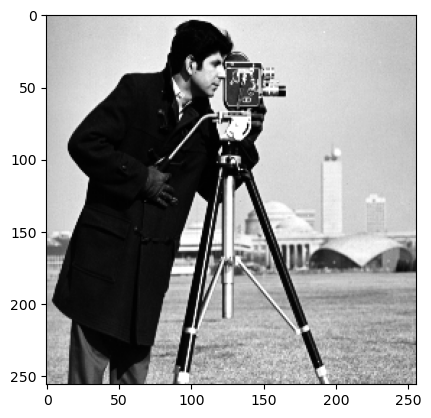

In [66]:
import cv2,numpy as np,matplotlib.pyplot as plt

img = cv2.imread("cam.png",0)
plt.imshow(img,cmap='grey')

def show_img(images,titles):
    n = len(images)
    fig,ax = plt.subplots(1,n,figsize=(10,10))
    for i,axx in enumerate(ax):
        axx.imshow(images[i],cmap='grey')
        axx.set_title(titles[i])
        axx.axis("off")

    plt.tight_layout()
    plt.show()

# FILTERS : ROBERT AND PREWITT

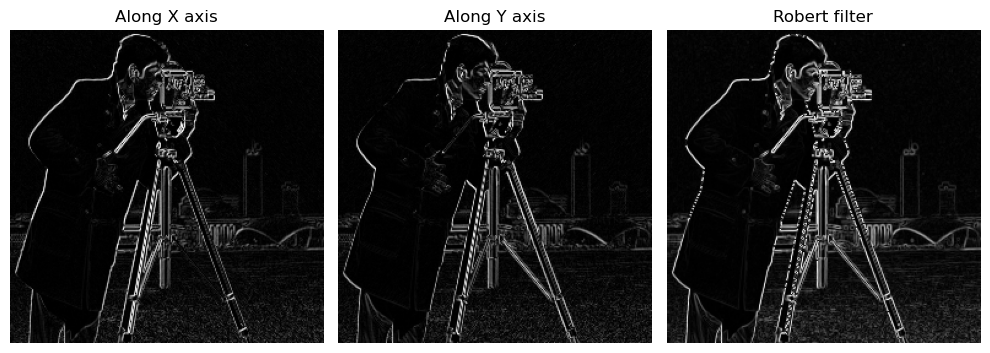

In [69]:
# ROBERT filter
def robert_filter(img):
    rob_x = np.array([[1,0],[0,-1]])
    rob_y = np.array([[0,1],[-1,0]])

    grad_x = cv2.filter2D(img,cv2.CV_64F,rob_x)
    grad_y = cv2.filter2D(img,cv2.CV_64F,rob_y)

    robert_filt = np.uint8(np.sqrt(np.square(grad_x)+np.square(grad_y)))

    return abs(grad_x),abs(grad_y),robert_filt

grad_x,grad_y,res = robert_filter(img)
show_img([grad_x,grad_y,res],["Along X axis","Along Y axis","Robert filter"])

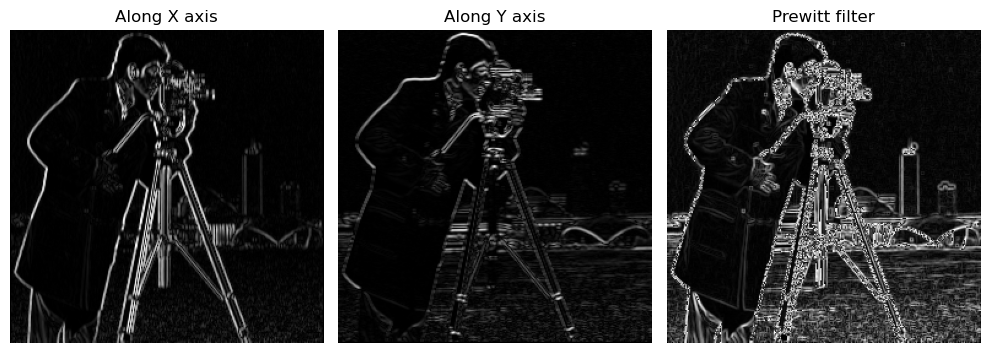

In [70]:
# PREWITT filter
def prewitt_filter(img):
    pr_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
    pr_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]])

    grad_x = cv2.filter2D(img,cv2.CV_64F,pr_x)
    grad_y = cv2.filter2D(img,cv2.CV_64F,pr_y)

    pre_filt = np.uint8(np.sqrt(np.square(grad_x)+np.square(grad_y)))

    return abs(grad_x),abs(grad_y),pre_filt

grad_x,grad_y,res = prewitt_filter(img)
show_img([grad_x,grad_y,res],["Along X axis","Along Y axis","Prewitt filter"])

# CANNY EDGE DETECTION

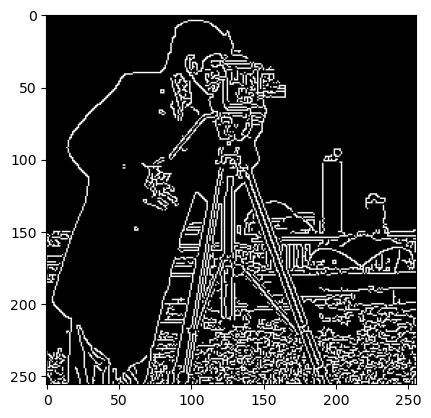

In [72]:
#Builtin
canny = cv2.Canny(img,50,150,(3,3))
plt.imshow(canny,cmap='grey')

# Manual
Noise reduction;
Gradient calculation;
Non-maximum suppression;
Double threshold;
Edge Trackimng by Hysteresis.

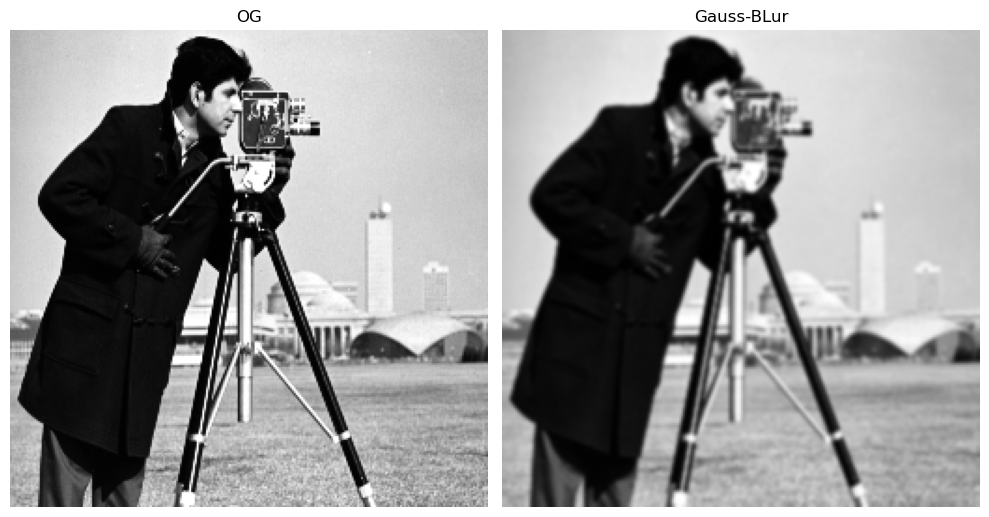

In [74]:
#Gaussian blurring
def gauss_blur(img,ks,sigma):
    size = ks//2
    x, y = np.mgrid[-size:size+1, -size:size+1]

    const = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * const
    g /= g.sum()
    return g

gauss_kernel = gauss_blur(img,5,1)
new_img = cv2.filter2D(img,-1,gauss_kernel)
#gauss_kernel
show_img([img,new_img],['OG','Gauss-BLur'])


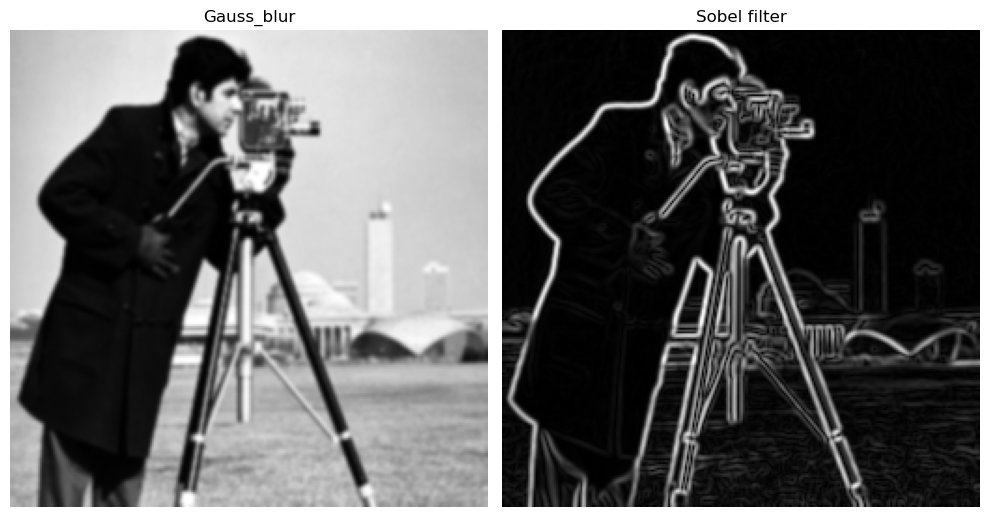

In [75]:
 
#Sobel filter
def sobel_filters(img):
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)
    
    Ix = cv2.filter2D(img,cv2.CV_64F,Kx)
    
    Iy = cv2.filter2D(img,cv2.CV_64F,Ky)
    
    G =  np.hypot(Ix, Iy)
    G = G / G.max() * 255
    theta = np.arctan2(Iy, Ix)
    
    return (G, theta)

res,theta = sobel_filters(new_img)
show_img([new_img,res],["Gauss_blur","Sobel filter"])

 

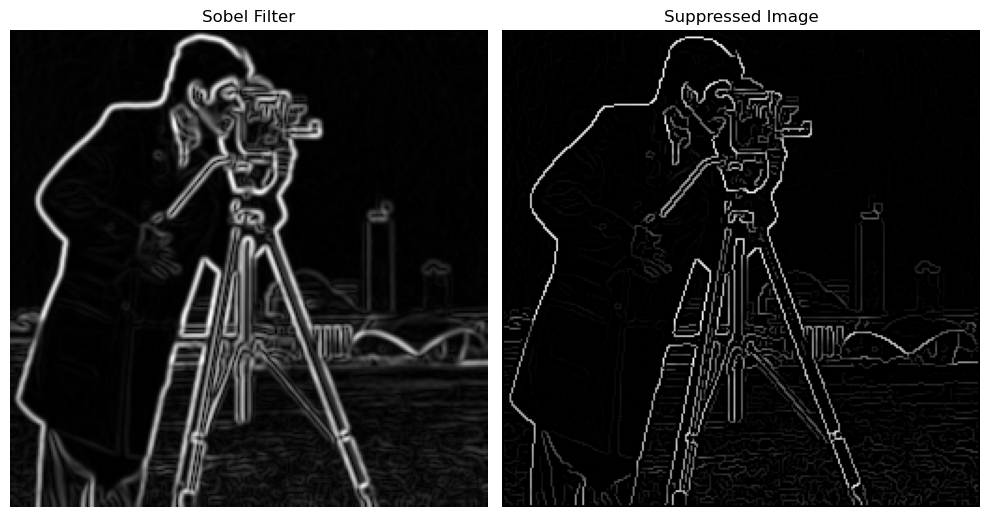

In [76]:
def non_max_suppression(img, D):
    M, N = img.shape
    Z = np.zeros((M,N), dtype=np.int32)
    angle = D * 180. / np.pi
    angle[angle < 0] += 180

    
    for i in range(1,M-1):
        for j in range(1,N-1):
            try:
                q = 255
                r = 255
                
               #angle 0
                if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                    q = img[i, j+1]
                    r = img[i, j-1]
                #angle 45
                elif (22.5 <= angle[i,j] < 67.5):
                    q = img[i+1, j-1]
                    r = img[i-1, j+1]
                #angle 90
                elif (67.5 <= angle[i,j] < 112.5):
                    q = img[i+1, j]
                    r = img[i-1, j]
                #angle 135
                elif (112.5 <= angle[i,j] < 157.5):
                    q = img[i-1, j-1]
                    r = img[i+1, j+1]

                if (img[i,j] >= q) and (img[i,j] >= r):
                    Z[i,j] = img[i,j]
                else:
                    Z[i,j] = 0

            except IndexError as e:
                pass
    
    return Z

Suppressed_img = non_max_suppression(res,theta)
show_img([res,Suppressed_img],['Sobel Filter','Suppressed Image'])


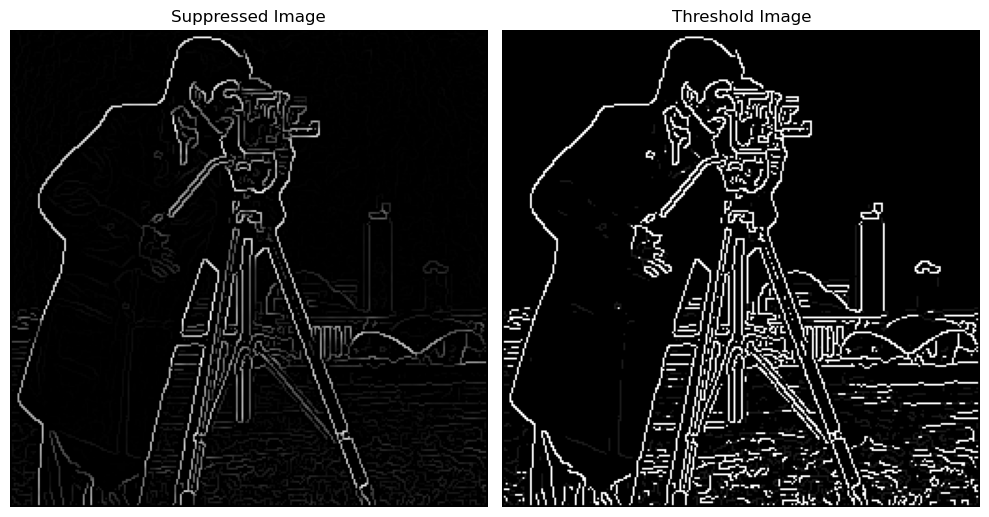

In [77]:
import cv2
import numpy as np

# Thresholding function
def threshold(img, lowThresholdRatio=0.05, highThresholdRatio=0.09):
    highThreshold = img.max() * highThresholdRatio
    lowThreshold = img.max() * lowThresholdRatio

    M, N = img.shape
    res = np.zeros((M, N), dtype=np.int32)

    weak = np.int32(25)
    strong = np.int32(255)

    # Classify pixels
    strong_i, strong_j = np.where(img >= highThreshold)
    zeros_i, zeros_j = np.where(img < lowThreshold)
    weak_i, weak_j = np.where((img < highThreshold) & (img >= lowThreshold))

    # Assign pixel values
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak

    return (res, weak, strong)
    # Apply thresholding
thres_img, wk, strng = threshold(Suppressed_img)
show_img([Suppressed_img, thres_img], ['Suppressed Image', 'Threshold Image'])


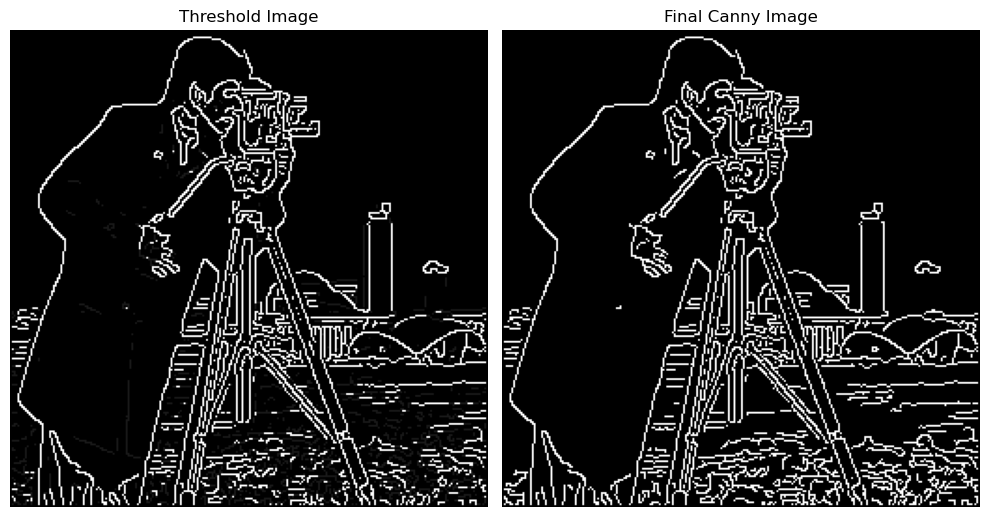

In [78]:
# Hysteresis function
def hysteresis(img, weak, strong=255):
    M, N = img.shape  
    img_copy = img.copy()

    for i in range(1, M-1):
        for j in range(1, N-1):
            if img_copy[i, j] == weak:
                if ((img_copy[i+1, j-1] == strong) or (img_copy[i+1, j] == strong) or (img_copy[i+1, j+1] == strong) or
                    (img_copy[i, j-1] == strong) or (img_copy[i, j+1] == strong) or
                    (img_copy[i-1, j-1] == strong) or (img_copy[i-1, j] == strong) or (img_copy[i-1, j+1] == strong)):
                    img_copy[i, j] = strong
                else:
                    img_copy[i, j] = 0
    
    return img_copy


# Apply hysteresis
Fin_img = hysteresis(thres_img, wk, strng)
show_img([thres_img, Fin_img], ['Threshold Image', 'Final Canny Image'])

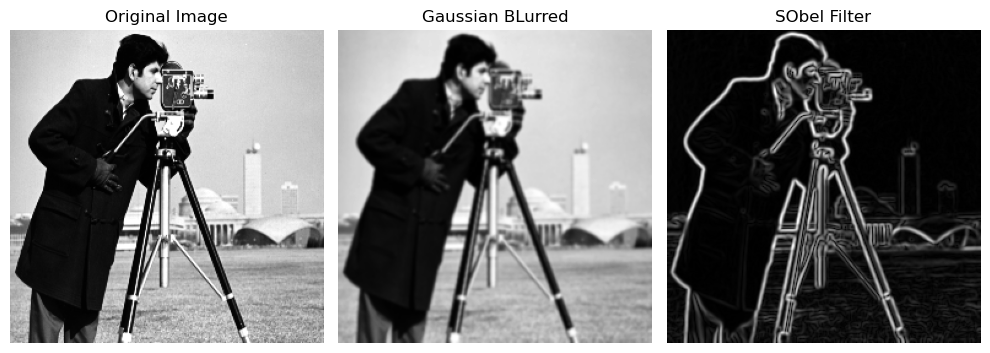

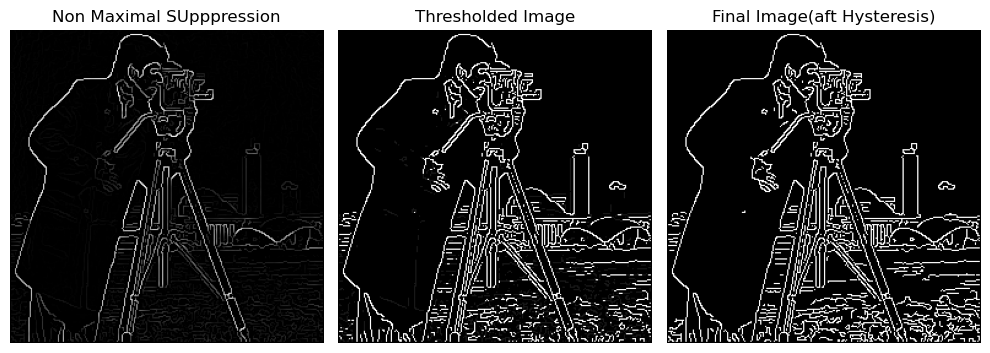

In [80]:
show_img([img,new_img,res],['Original Image','Gaussian BLurred','SObel Filter'])
show_img([Suppressed_img,thres_img,Fin_img],['Non Maximal SUpppression','Thresholded Image','Final Image(aft Hysteresis)'])

# LAPLACIAN OF GAUSSIAN

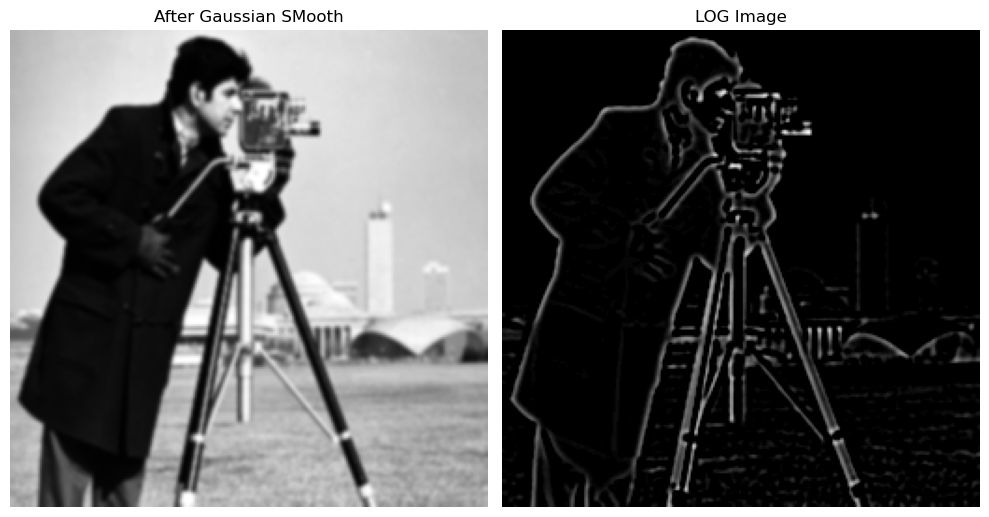

In [82]:
def log_filt(img,size,sigma):

    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1
        
    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))

    result = cv2.filter2D(img, -1, kernel)

    return result

log_img = log_filt(new_img,7,1)
show_img([new_img,log_img],['After Gaussian SMooth','LOG Image'])


In [83]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def log_filt(img, size=None, sigma=1):
    if size is None:
        size = max(3, int(6 * sigma + 1))

    if size % 2 == 0:
        size += 1

    half_size = size // 2
    x, y = np.meshgrid(np.arange(-half_size, half_size + 1), np.arange(-half_size, half_size + 1))

    kernel = -(1 / (np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel - np.mean(kernel)
    kernel = kernel / np.sum(kernel)

    img = img.astype(np.float32)
    result = cv2.filter2D(img, -1, kernel)

    return result

#OPTIONAL
"""
def detect_zero_crossings(image, threshold=0.01):
    image = image.astype(np.float32)
    edges = np.zeros_like(image, dtype=np.uint8)
    
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            neighbors = [
                image[i-1, j], image[i+1, j],  
                image[i, j-1], image[i, j+1],  
                image[i-1, j-1], image[i-1, j+1],  
                image[i+1, j-1], image[i+1, j+1]
            ]
            epsilon = 1e-6
            if np.isfinite(image[i, j]) and all(np.isfinite(neighbors)):
                if any(image[i, j] * neighbor < 0 and abs(image[i, j] - neighbor) > threshold + epsilon for neighbor in neighbors):
                    edges[i, j] = 255  
    
    return edges

"""


log_img = log_filt(new_img, size=7, sigma=1)
#edg = detect_zero_crossings(log_img)

#show_img([new_img, log_img, edg], ['Original Image', 'LoG Image', 'Zero-Crossing Edges'])


# Differentiation of Gaussian

In [86]:
size = 5
sigma = 1
half_size = size // 2
x, y = np.meshgrid(np.arange(-half_size, half_size + 1), np.arange(-half_size, half_size + 1))

    # Compute Laplacian of Gaussian kernel
kernel = -(1 / (np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
kernel = kernel - np.mean(kernel)  # Subtract mean to avoid bias
kernel = kernel / np.sum(kernel)   # Normalize kernel to sum to zero
kernel

array([[ 3.07031668e+14,  5.91365078e+14,  6.42275193e+14,
         5.91365078e+14,  3.07031668e+14],
       [ 5.91365078e+14,  7.78865955e+13, -1.18682051e+15,
         7.78865955e+13,  5.91365078e+14],
       [ 6.42275193e+14, -1.18682051e+15, -4.09241241e+15,
        -1.18682051e+15,  6.42275193e+14],
       [ 5.91365078e+14,  7.78865955e+13, -1.18682051e+15,
         7.78865955e+13,  5.91365078e+14],
       [ 3.07031668e+14,  5.91365078e+14,  6.42275193e+14,
         5.91365078e+14,  3.07031668e+14]])

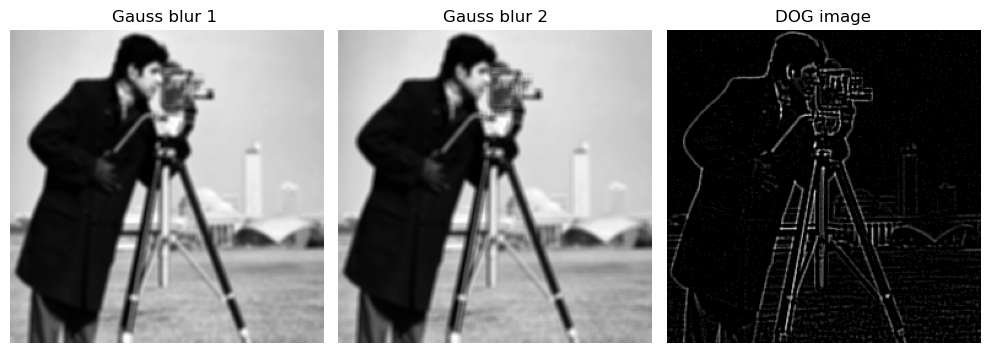

In [112]:
def DOG(image, sigma):
    """Difference of Gaussian (DoG) function."""
    sigma1 = sigma / np.sqrt(2)
    sigma2 = sigma * np.sqrt(2)
    
    gauss_kernel1 = gauss_blur(image, 5, sigma1)
    gauss_kernel2 = gauss_blur(image, 5, sigma2)

    blur1 = cv2.filter2D(img,-1,gauss_kernel1)
    blur2 = cv2.filter2D(img,-1,gauss_kernel2)

    dog_image = cv2.subtract(blur1, blur2)  # Use OpenCV subtract to avoid underflow issues
    
    return blur1, blur2, dog_image

#sigma1 = sigma/sqrt(2) , sigma2 = sigma*sqrt(2)

b1,b2,dog_img = DOG(img,3)
show_img([b1,b2,dog_img],['Gauss blur 1 ' ,'Gauss blur 2','DOG image'])